# Social Network Ads - Purchase Prediction (Classification)

---

## 1. Problem Statement

### 1.1 Business Context

Social networking platforms generate significant revenue through targeted advertisements. A key challenge for businesses that advertise on these platforms is understanding which users are most likely to purchase a product after being exposed to an advertisement. Accurate prediction of purchase behavior allows companies to optimize their advertising spend, improve conversion rates, and deliver more relevant ads to users who are genuinely interested.

This project addresses the problem from the perspective of a social networking company that has collected data on user demographics (age, gender, estimated salary) along with whether the user ultimately purchased the advertised product. The goal is to build a classification model that can predict whether a new user will purchase a product based on their demographic profile.

### 1.2 Objective

The objective is to build, evaluate, and compare multiple classification models that predict whether a user will purchase a product (binary classification: Purchased = 0 or 1) based on the following user attributes:

- Age
- Gender
- Estimated Salary

The notebook will cover:

- Comprehensive Exploratory Data Analysis (EDA) to understand the data and its patterns.
- Data preprocessing including encoding, scaling, and train-test splitting.
- Training and evaluation of multiple classification algorithms: Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Decision Tree, Random Forest, Naive Bayes, and XGBoost.
- Hyperparameter tuning using GridSearchCV for key models.
- Comparison of all models on standard classification metrics (accuracy, precision, recall, F1-score, ROC-AUC).

### 1.3 Dataset Description

The Social Network Ads dataset contains 400 records with the following columns:

| Column | Description |
|---|---|
| User ID | Unique identifier for each user (not a predictive feature) |
| Gender | Gender of the user (Male / Female) |
| Age | Age of the user |
| EstimatedSalary | Estimated annual salary of the user |
| Purchased (Target) | Whether the user purchased the product (0 = No, 1 = Yes) |

### 1.4 Approach

1. Data Loading and Initial Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (encoding, scaling, splitting)
4. Model Training and Evaluation (7 classifiers)
5. Hyperparameter Tuning (GridSearchCV)
6. Final Comparison and Conclusion


---
## 2. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All libraries imported successfully.")


All libraries imported successfully.


---
## 3. Data Loading and Initial Inspection


In [2]:
# Load the dataset
df = pd.read_csv("Social_Network_Ads.csv")
print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)


Dataset loaded successfully.
Shape of the dataset: (400, 5)


In [3]:
# Display the first 10 rows
df.head(10)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15000599,Male,42,82000,1
1,15003402,Female,45,139000,1
2,15006814,Male,30,90000,0
3,15007540,Male,38,29000,0
4,15012038,Male,55,137000,1
5,15015474,Male,21,145000,1
6,15020422,Male,29,32000,0
7,15022056,Male,43,45000,0
8,15026225,Male,55,25000,0
9,15027824,Female,34,67000,0


In [4]:
# Display the last 5 rows
df.tail()


,User ID,Gender,Age,EstimatedSalary,Purchased
395,15988210,Female,36,17000,0
396,15988712,Male,45,49000,1
397,15992842,Female,41,26000,0
398,15992948,Female,21,64000,0
399,15999816,Female,50,130000,1


In [5]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [6]:
# Statistical summary
df.describe()


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.00000
mean,1.548762e+07,39.670000,84070.000000,0.50250
std,2.917693e+05,12.320535,38869.231313,0.50062
min,1.500060e+07,18.000000,15000.000000,0.00000
25%,1.523076e+07,29.000000,49000.000000,0.00000
50%,1.548491e+07,40.000000,85000.000000,1.00000
75%,1.573965e+07,50.000000,118250.000000,1.00000
max,1.599982e+07,60.000000,150000.000000,1.00000


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())


Missing values per column:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Total missing values: 0


In [8]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [9]:
# Check unique values for categorical columns
print("Unique Genders:", df['Gender'].unique())
print("Unique Purchased values:", df['Purchased'].unique())
print("Number of unique User IDs:", df['User ID'].nunique())


Unique Genders: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique Purchased values: [1 0]
Number of unique User IDs: 400


---
## 4. Exploratory Data Analysis (EDA)


### 4.1 Target Variable Distribution


Target variable distribution:
Purchased
1    201
0    199
Name: count, dtype: int64

Percentage - Not Purchased (0): 49.8%
Percentage - Purchased (1): 50.2%


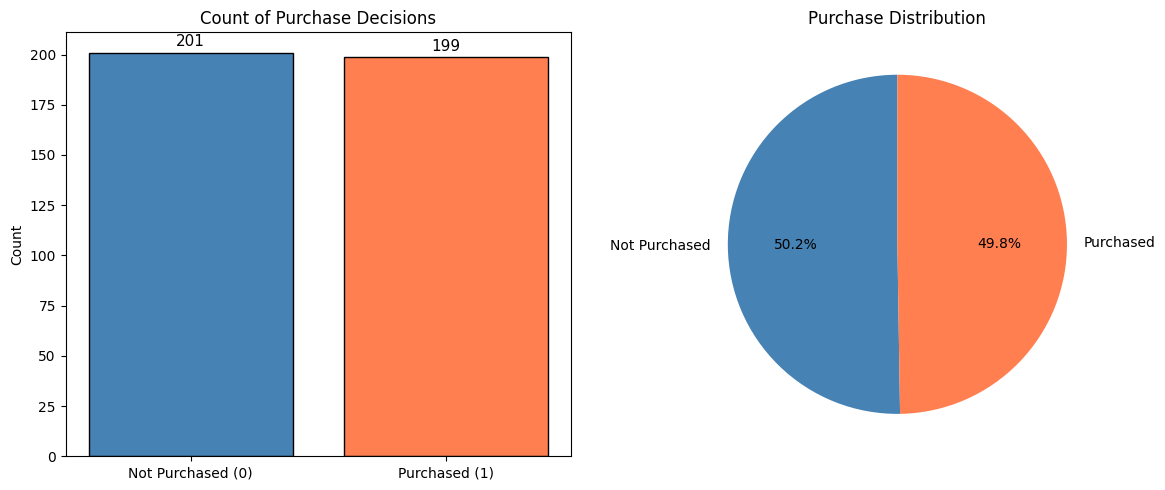

In [10]:
# Distribution of the target variable
purchased_counts = df['Purchased'].value_counts()
print("Target variable distribution:")
print(purchased_counts)
print()
print(f"Percentage - Not Purchased (0): {purchased_counts[0]/len(df)*100:.1f}%")
print(f"Percentage - Purchased (1): {purchased_counts[1]/len(df)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Not Purchased (0)', 'Purchased (1)'], purchased_counts.values,
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Count of Purchase Decisions')
axes[0].set_ylabel('Count')
for i, v in enumerate(purchased_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=11)

axes[1].pie(purchased_counts.values, labels=['Not Purchased', 'Purchased'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Purchase Distribution')

plt.tight_layout()
plt.show()


### 4.2 Gender Distribution


Gender distribution:
Gender
Female    206
Male      194
Name: count, dtype: int64


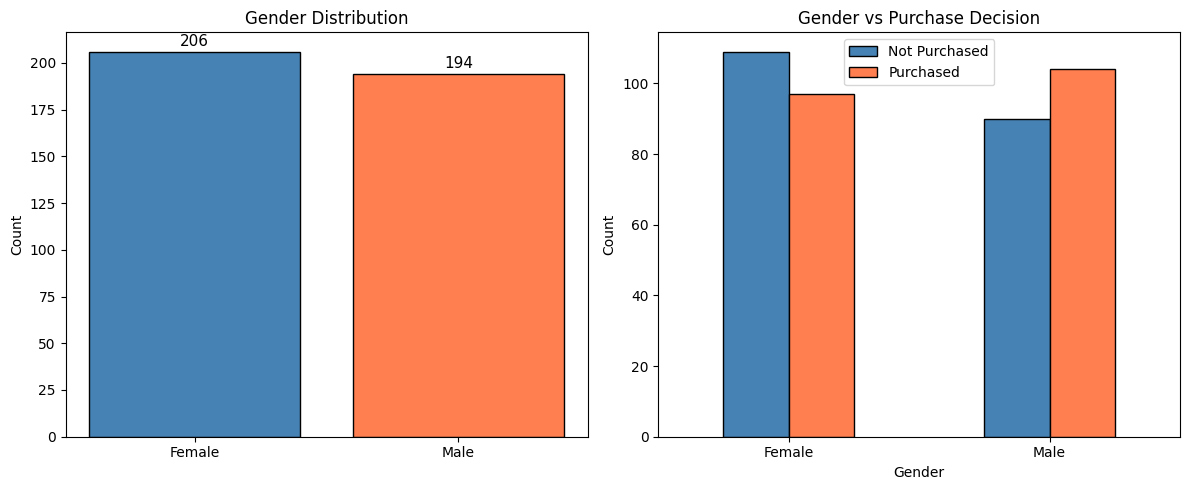

In [11]:
# Gender distribution
gender_counts = df['Gender'].value_counts()
print("Gender distribution:")
print(gender_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=11)

# Gender vs Purchase
gender_purchase = pd.crosstab(df['Gender'], df['Purchased'])
gender_purchase.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Gender vs Purchase Decision')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Not Purchased', 'Purchased'])

plt.tight_layout()
plt.show()


### 4.3 Age Distribution and Analysis


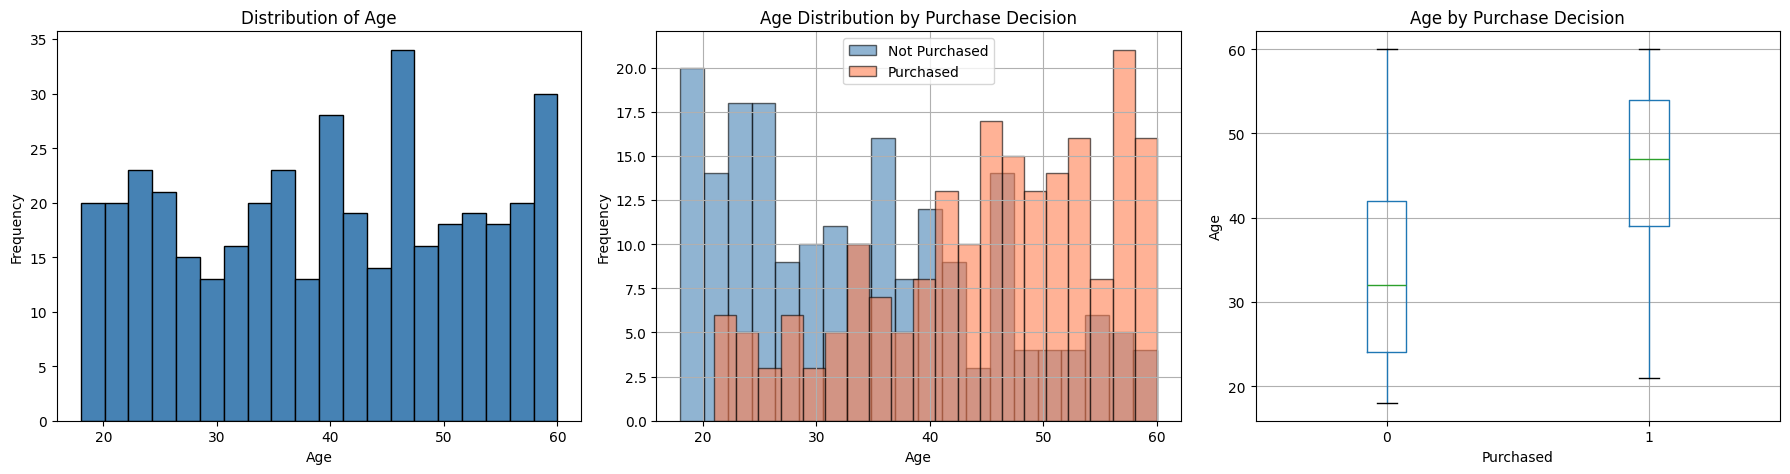

Mean age of purchasers: 45.31
Mean age of non-purchasers: 33.97


In [12]:
# Age distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Age by purchase decision
df[df['Purchased'] == 0]['Age'].hist(bins=20, alpha=0.6, color='steelblue', edgecolor='black',
                                      label='Not Purchased', ax=axes[1])
df[df['Purchased'] == 1]['Age'].hist(bins=20, alpha=0.6, color='coral', edgecolor='black',
                                      label='Purchased', ax=axes[1])
axes[1].set_title('Age Distribution by Purchase Decision')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Boxplot of Age by Purchase
df.boxplot(column='Age', by='Purchased', ax=axes[2])
axes[2].set_title('Age by Purchase Decision')
axes[2].set_xlabel('Purchased')
axes[2].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Mean age of purchasers:", df[df['Purchased'] == 1]['Age'].mean().round(2))
print("Mean age of non-purchasers:", df[df['Purchased'] == 0]['Age'].mean().round(2))


### 4.4 Salary Distribution and Analysis


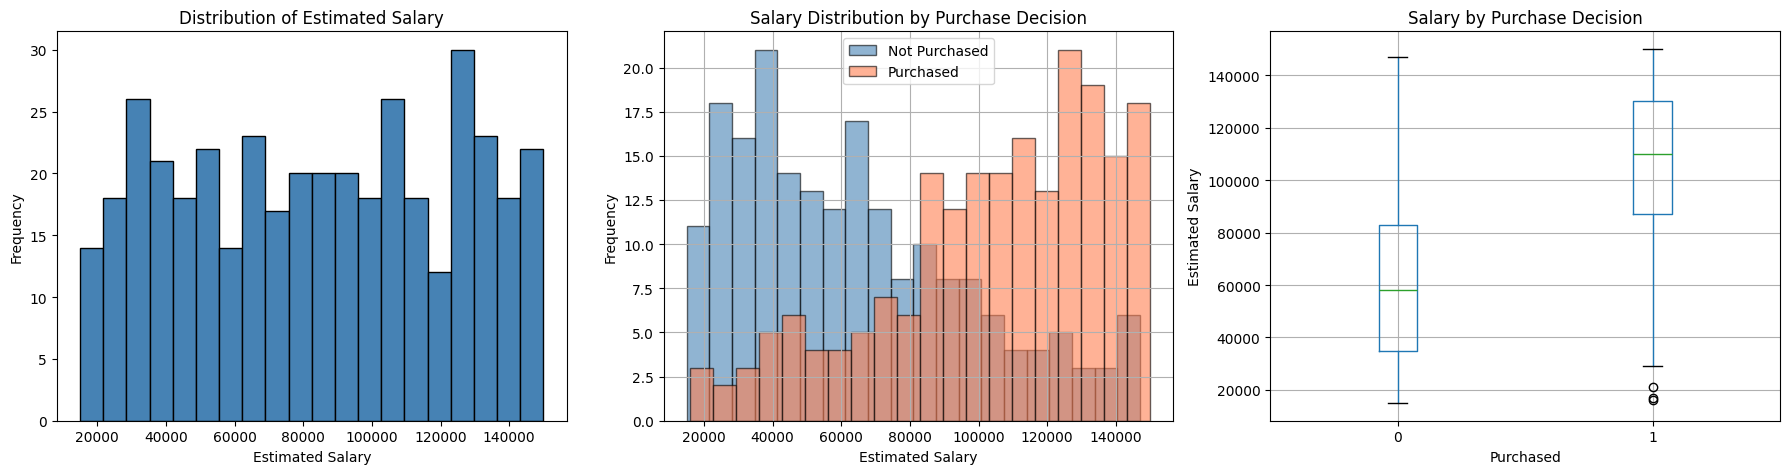

Mean salary of purchasers: 104119.4
Mean salary of non-purchasers: 63819.1


In [13]:
# Salary distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['EstimatedSalary'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Estimated Salary')
axes[0].set_xlabel('Estimated Salary')
axes[0].set_ylabel('Frequency')

# Salary by purchase decision
df[df['Purchased'] == 0]['EstimatedSalary'].hist(bins=20, alpha=0.6, color='steelblue', edgecolor='black',
                                                   label='Not Purchased', ax=axes[1])
df[df['Purchased'] == 1]['EstimatedSalary'].hist(bins=20, alpha=0.6, color='coral', edgecolor='black',
                                                   label='Purchased', ax=axes[1])
axes[1].set_title('Salary Distribution by Purchase Decision')
axes[1].set_xlabel('Estimated Salary')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Boxplot of Salary by Purchase
df.boxplot(column='EstimatedSalary', by='Purchased', ax=axes[2])
axes[2].set_title('Salary by Purchase Decision')
axes[2].set_xlabel('Purchased')
axes[2].set_ylabel('Estimated Salary')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Mean salary of purchasers:", df[df['Purchased'] == 1]['EstimatedSalary'].mean().round(2))
print("Mean salary of non-purchasers:", df[df['Purchased'] == 0]['EstimatedSalary'].mean().round(2))


### 4.5 Scatter Plot: Age vs Salary (Colored by Purchase)


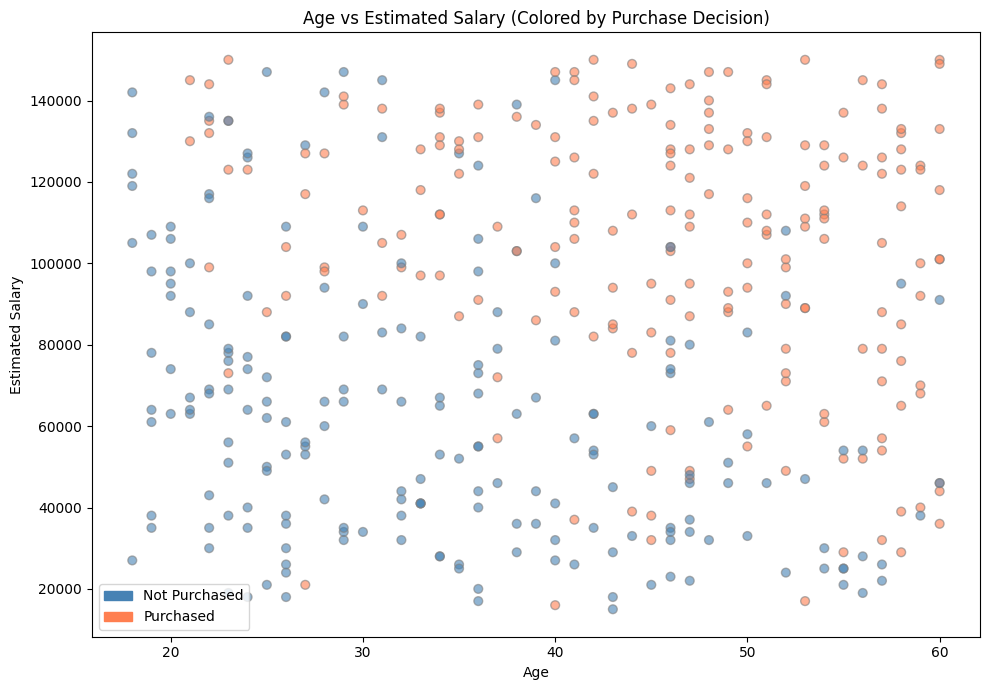

In [14]:
# Scatter plot of Age vs Salary colored by purchase decision
plt.figure(figsize=(10, 7))
colors = df['Purchased'].map({0: 'steelblue', 1: 'coral'})
plt.scatter(df['Age'], df['EstimatedSalary'], c=colors, alpha=0.6, edgecolor='grey', s=40)

# Create custom legend
import matplotlib.patches as mpatches
not_purchased = mpatches.Patch(color='steelblue', label='Not Purchased')
purchased = mpatches.Patch(color='coral', label='Purchased')
plt.legend(handles=[not_purchased, purchased])

plt.title('Age vs Estimated Salary (Colored by Purchase Decision)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.tight_layout()
plt.show()


### 4.6 Correlation Analysis


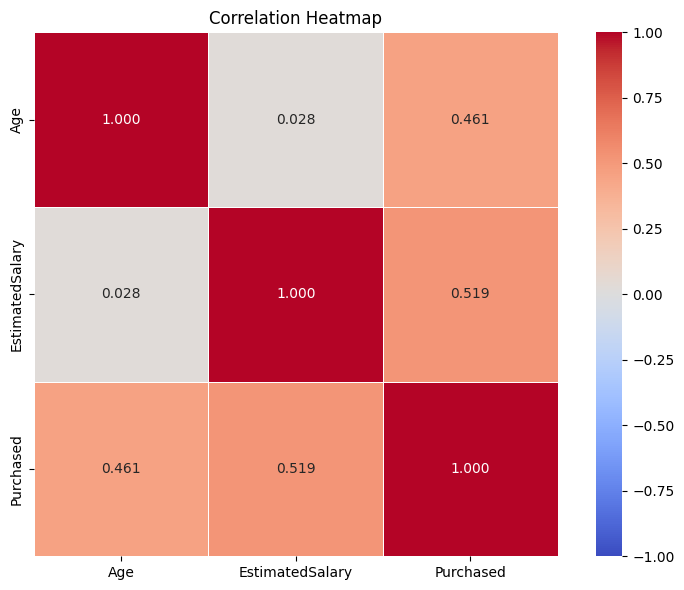

Correlation with Purchased:
EstimatedSalary    0.519052
Age                0.460923
Name: Purchased, dtype: float64


In [15]:
# Correlation heatmap (numeric columns only)
numeric_df = df[['Age', 'EstimatedSalary', 'Purchased']]

plt.figure(figsize=(8, 6))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5,
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Correlation with Purchased:")
print(corr_matrix['Purchased'].drop('Purchased').sort_values(ascending=False))


### 4.7 Age Group Analysis


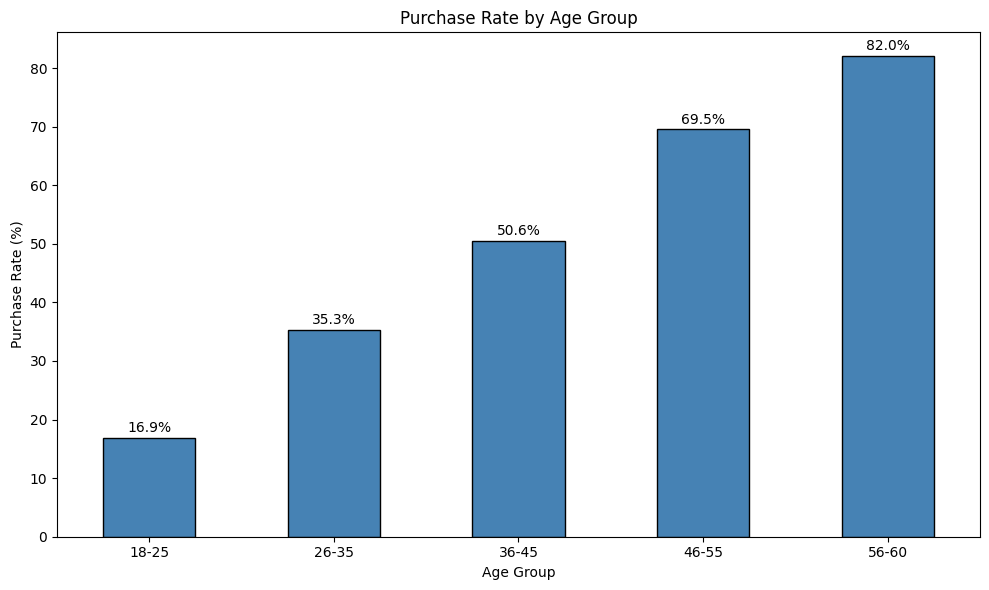

In [16]:
# Create age groups and analyze purchase rates
bins = [17, 25, 35, 45, 55, 61]
labels = ['18-25', '26-35', '36-45', '46-55', '56-60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_purchase = df.groupby('AgeGroup', observed=True)['Purchased'].mean() * 100

plt.figure(figsize=(10, 6))
age_group_purchase.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Purchase Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(age_group_purchase.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Drop the temporary column
df = df.drop(columns=['AgeGroup'])


### 4.8 Observations from EDA

Key findings:

1. The target variable is reasonably balanced between purchased and not purchased.
2. Both Age and EstimatedSalary show differentiation between purchasers and non-purchasers.
3. Older users with higher salaries are more likely to purchase the advertised product.
4. The Age vs Salary scatter plot reveals a pattern where purchase decisions cluster in the higher age and higher salary region.
5. Gender shows relatively balanced distribution with no extreme skew in purchase behavior.
6. There are no missing values or duplicate records in the dataset.
7. User ID is a unique identifier and does not carry predictive value.


---
## 5. Data Preprocessing


### 5.1 Drop Non-Predictive Columns


In [17]:
# Drop User ID as it is not a predictive feature
data = df.copy()
data = data.drop(columns=['User ID'])
print("Shape after dropping User ID:", data.shape)
data.head()


Shape after dropping User ID: (400, 4)


,Gender,Age,EstimatedSalary,Purchased
0,Male,42,82000,1
1,Female,45,139000,1
2,Male,30,90000,0
3,Male,38,29000,0
4,Male,55,137000,1


### 5.2 Encode Categorical Variables


In [18]:
# Encode Gender: Male = 1, Female = 0
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
print("Gender encoding: Female = 0, Male = 1")
print(data['Gender'].value_counts())
data.head()


Gender encoding: Female = 0, Male = 1
Gender
0    206
1    194
Name: count, dtype: int64


,Gender,Age,EstimatedSalary,Purchased
0,1,42,82000,1
1,0,45,139000,1
2,1,30,90000,0
3,1,38,29000,0
4,1,55,137000,1


### 5.3 Separate Features and Target


In [19]:
# Separate features and target
X = data.drop(columns=['Purchased'])
y = data['Purchased']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print()
print("Features:")
print(X.head())


Feature matrix shape: (400, 3)
Target vector shape: (400,)

Features:
   Gender  Age  EstimatedSalary
0       1   42            82000
1       0   45           139000
2       1   30            90000
3       1   38            29000
4       1   55           137000


### 5.4 Train-Test Split


In [20]:
# Split into training and testing sets (75-25 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print()
print(f"Training target distribution:")
print(y_train.value_counts())
print()
print(f"Test target distribution:")
print(y_test.value_counts())


Training set size: 300 samples
Test set size: 100 samples

Training target distribution:
Purchased
1    151
0    149
Name: count, dtype: int64

Test target distribution:
Purchased
1    50
0    50
Name: count, dtype: int64


### 5.5 Feature Scaling

Feature scaling is critical for algorithms like Logistic Regression, SVM, and KNN that are sensitive to the magnitude of features. Age ranges from 18-60 while EstimatedSalary ranges from 15,000-150,000, so scaling ensures both features contribute equally.


In [21]:
# Apply Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print()
print("Training set statistics after scaling:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().round(3))


Scaling complete.

Training set statistics after scaling:
        Gender      Age  EstimatedSalary
count  300.000  300.000          300.000
mean    -0.000    0.000           -0.000
std      1.002    1.002            1.002
min     -0.954   -1.822           -1.771
25%     -0.954   -0.838           -0.884
50%     -0.954    0.064            0.069
75%      1.048    0.802            0.871
max      1.048    1.622            1.752


---
## 6. Model Training and Evaluation

We train and evaluate seven classification algorithms on this dataset. For each model, we compute accuracy, precision, recall, F1-score, and ROC-AUC on the test set.


### 6.1 Helper Function for Evaluation


In [22]:
# Define a helper function to train, predict, and evaluate a model
def evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te):
    """Train a model and return evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # For ROC-AUC, we need probability estimates
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
    else:
        y_prob = y_pred

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_prob)

    # Cross-validation score on training set
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f"--- {model_name} ---")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Precision:      {prec:.4f}")
    print(f"Recall:         {rec:.4f}")
    print(f"F1-Score:       {f1:.4f}")
    print(f"ROC-AUC:        {roc_auc:.4f}")
    print(f"CV Accuracy:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'CV Accuracy': round(cv_scores.mean(), 4),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model
    }

print("Evaluation function defined.")


Evaluation function defined.


### 6.2 Logistic Regression


In [23]:
lr_model = LogisticRegression(random_state=0)
lr_results = evaluate_model(lr_model, 'Logistic Regression', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, lr_results['y_pred']))


--- Logistic Regression ---


Test Accuracy:  0.7900
Precision:      0.7843
Recall:         0.8000
F1-Score:       0.7921
ROC-AUC:        0.8604
CV Accuracy:    0.8367 (+/- 0.0245)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        50
           1       0.78      0.80      0.79        50

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



### 6.3 K-Nearest Neighbors (KNN)


In [24]:
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_results = evaluate_model(knn_model, 'KNN (k=5)', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, knn_results['y_pred']))


--- KNN (k=5) ---
Test Accuracy:  0.8200
Precision:      0.8077
Recall:         0.8400
F1-Score:       0.8235
ROC-AUC:        0.8562
CV Accuracy:    0.7600 (+/- 0.0226)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        50
           1       0.81      0.84      0.82        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



### 6.4 Support Vector Machine (SVM) - RBF Kernel


In [25]:
svm_model = SVC(kernel='rbf', random_state=0, probability=True)
svm_results = evaluate_model(svm_model, 'SVM (RBF)', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, svm_results['y_pred']))


--- SVM (RBF) ---


Test Accuracy:  0.8000
Precision:      0.7885
Recall:         0.8200
F1-Score:       0.8039
ROC-AUC:        0.8640
CV Accuracy:    0.8133 (+/- 0.0287)

Classification Report:


              precision    recall  f1-score   support

           0       0.81      0.78      0.80        50
           1       0.79      0.82      0.80        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



### 6.5 Decision Tree Classifier


In [26]:
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_results = evaluate_model(dt_model, 'Decision Tree', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, dt_results['y_pred']))


--- Decision Tree ---
Test Accuracy:  0.7700
Precision:      0.7872
Recall:         0.7400
F1-Score:       0.7629
ROC-AUC:        0.7700
CV Accuracy:    0.7167 (+/- 0.0408)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.78        50
           1       0.79      0.74      0.76        50

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



### 6.6 Random Forest Classifier


In [27]:
rf_model = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf_results = evaluate_model(rf_model, 'Random Forest', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, rf_results['y_pred']))


--- Random Forest ---
Test Accuracy:  0.7800
Precision:      0.7917
Recall:         0.7600
F1-Score:       0.7755
ROC-AUC:        0.8628
CV Accuracy:    0.7500 (+/- 0.0211)

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        50
           1       0.79      0.76      0.78        50

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



### 6.7 Naive Bayes


In [28]:
nb_model = GaussianNB()
nb_results = evaluate_model(nb_model, 'Naive Bayes', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, nb_results['y_pred']))


--- Naive Bayes ---
Test Accuracy:  0.7900
Precision:      0.7843
Recall:         0.8000
F1-Score:       0.7921
ROC-AUC:        0.8500
CV Accuracy:    0.8200 (+/- 0.0267)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        50
           1       0.78      0.80      0.79        50

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



### 6.8 XGBoost Classifier


In [29]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0, verbosity=0)
xgb_results = evaluate_model(xgb_model, 'XGBoost', X_train_scaled, X_test_scaled, y_train, y_test)

print("Classification Report:")
print(classification_report(y_test, xgb_results['y_pred']))


--- XGBoost ---
Test Accuracy:  0.7500
Precision:      0.7551
Recall:         0.7400
F1-Score:       0.7475
ROC-AUC:        0.8530
CV Accuracy:    0.7333 (+/- 0.0447)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75        50
           1       0.76      0.74      0.75        50

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100



---
## 7. Confusion Matrices


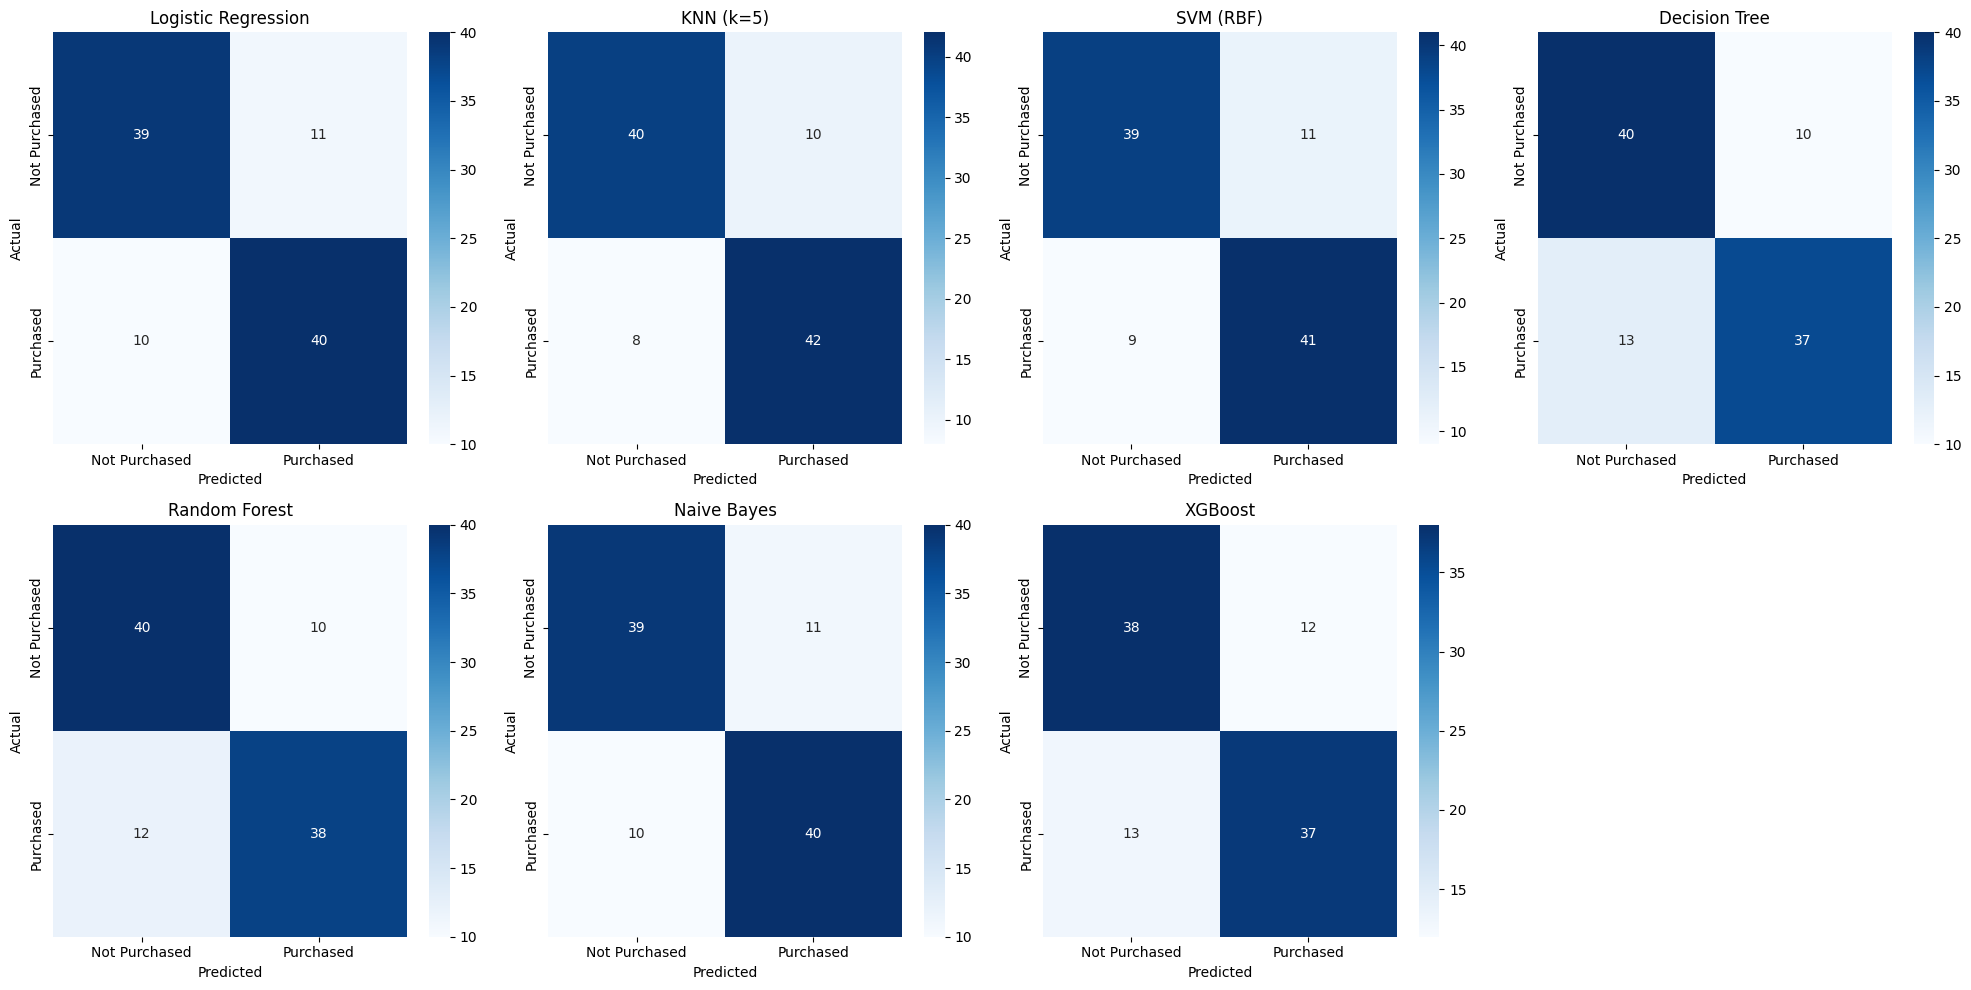

In [30]:
# Plot confusion matrices for all models
all_results = [lr_results, knn_results, svm_results, dt_results, rf_results, nb_results, xgb_results]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, result in enumerate(all_results):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Purchased', 'Purchased'],
                yticklabels=['Not Purchased', 'Purchased'])
    axes[i].set_title(result['Model'])
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Hide the empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()


---
## 8. ROC Curves


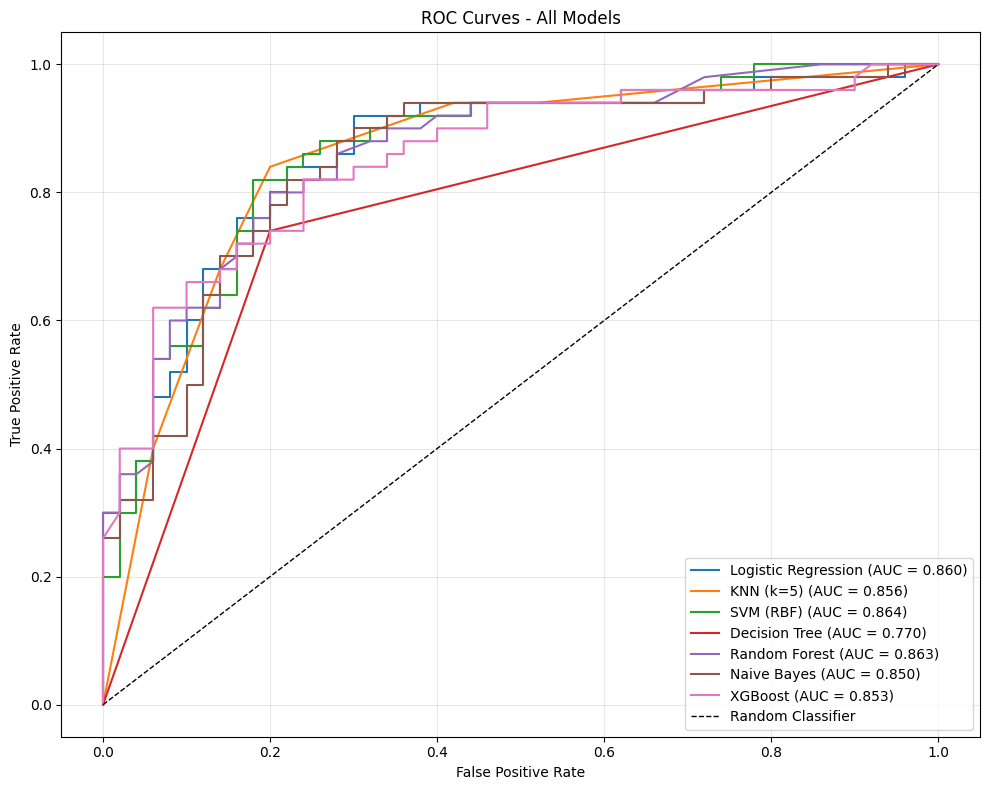

In [31]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for result in all_results:
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    auc_val = result['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{result['Model']} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 9. Hyperparameter Tuning (GridSearchCV)

We perform hyperparameter tuning on the most promising models to potentially improve their performance.


### 9.1 KNN - Optimal K Selection


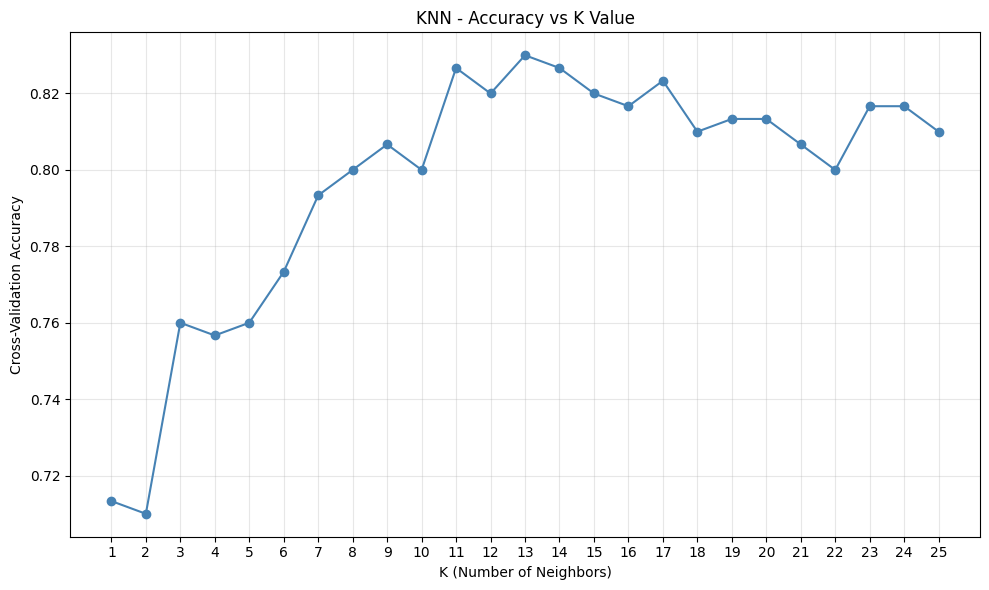

Best K value: 13 with CV Accuracy: 0.8300


In [32]:
# Find the optimal K for KNN
k_range = range(1, 26)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.title('KNN - Accuracy vs K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(k_scores)]
print(f"Best K value: {best_k} with CV Accuracy: {max(k_scores):.4f}")


In [33]:
# Retrain KNN with optimal K
knn_tuned = KNeighborsClassifier(n_neighbors=best_k)
knn_tuned_results = evaluate_model(knn_tuned, f'KNN (k={best_k})', X_train_scaled, X_test_scaled, y_train, y_test)


--- KNN (k=13) ---
Test Accuracy:  0.8100
Precision:      0.8039
Recall:         0.8200
F1-Score:       0.8119
ROC-AUC:        0.8742
CV Accuracy:    0.8300 (+/- 0.0245)



### 9.2 SVM - Hyperparameter Tuning


In [34]:
# GridSearchCV for SVM
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(SVC(probability=True, random_state=0), svm_param_grid,
                        cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

print(f"SVM - Best Parameters: {svm_grid.best_params_}")
print(f"SVM - Best CV Score: {svm_grid.best_score_:.4f}")

svm_tuned_results = evaluate_model(svm_grid.best_estimator_, 'SVM (Tuned)',
                                   X_train_scaled, X_test_scaled, y_train, y_test)


SVM - Best Parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
SVM - Best CV Score: 0.8433
--- SVM (Tuned) ---
Test Accuracy:  0.7900
Precision:      0.7736
Recall:         0.8200
F1-Score:       0.7961
ROC-AUC:        0.8548
CV Accuracy:    0.8433 (+/- 0.0249)



### 9.3 Random Forest - Hyperparameter Tuning


In [35]:
# GridSearchCV for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=0), rf_param_grid,
                       cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Random Forest - Best Parameters: {rf_grid.best_params_}")
print(f"Random Forest - Best CV Score: {rf_grid.best_score_:.4f}")

rf_tuned_results = evaluate_model(rf_grid.best_estimator_, 'Random Forest (Tuned)',
                                  X_train_scaled, X_test_scaled, y_train, y_test)


Random Forest - Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Random Forest - Best CV Score: 0.8033


--- Random Forest (Tuned) ---
Test Accuracy:  0.7800
Precision:      0.7692
Recall:         0.8000
F1-Score:       0.7843
ROC-AUC:        0.8698
CV Accuracy:    0.8033 (+/- 0.0194)



### 9.4 XGBoost - Hyperparameter Tuning


In [36]:
# GridSearchCV for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                       random_state=0, verbosity=0),
                        xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

print(f"XGBoost - Best Parameters: {xgb_grid.best_params_}")
print(f"XGBoost - Best CV Score: {xgb_grid.best_score_:.4f}")

xgb_tuned_results = evaluate_model(xgb_grid.best_estimator_, 'XGBoost (Tuned)',
                                   X_train_scaled, X_test_scaled, y_train, y_test)


XGBoost - Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
XGBoost - Best CV Score: 0.8033


--- XGBoost (Tuned) ---
Test Accuracy:  0.8200
Precision:      0.7857
Recall:         0.8800
F1-Score:       0.8302
ROC-AUC:        0.8798
CV Accuracy:    0.8033 (+/- 0.0414)



---
## 10. Final Model Comparison


### 10.1 Performance Summary Table


In [37]:
# Compile all results into a comparison table
all_final_results = [
    lr_results, knn_results, svm_results, dt_results, rf_results, nb_results, xgb_results,
    knn_tuned_results, svm_tuned_results, rf_tuned_results, xgb_tuned_results
]

comparison_data = []
for r in all_final_results:
    comparison_data.append({
        'Model': r['Model'],
        'Accuracy': r['Accuracy'],
        'Precision': r['Precision'],
        'Recall': r['Recall'],
        'F1-Score': r['F1-Score'],
        'ROC-AUC': r['ROC-AUC'],
        'CV Accuracy': r['CV Accuracy']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(by='Accuracy', ascending=False)
print("Model Comparison (Sorted by Accuracy):")
print()
print(comparison_df.to_string(index=False))


Model Comparison (Sorted by Accuracy):

                Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy
            KNN (k=5)      0.82     0.8077    0.84    0.8235   0.8562       0.7600
      XGBoost (Tuned)      0.82     0.7857    0.88    0.8302   0.8798       0.8033
           KNN (k=13)      0.81     0.8039    0.82    0.8119   0.8742       0.8300
            SVM (RBF)      0.80     0.7885    0.82    0.8039   0.8640       0.8133
  Logistic Regression      0.79     0.7843    0.80    0.7921   0.8604       0.8367
          Naive Bayes      0.79     0.7843    0.80    0.7921   0.8500       0.8200
          SVM (Tuned)      0.79     0.7736    0.82    0.7961   0.8548       0.8433
        Random Forest      0.78     0.7917    0.76    0.7755   0.8628       0.7500
Random Forest (Tuned)      0.78     0.7692    0.80    0.7843   0.8698       0.8033
        Decision Tree      0.77     0.7872    0.74    0.7629   0.7700       0.7167
              XGBoost      0.75     0.7551    0

### 10.2 Visual Comparison


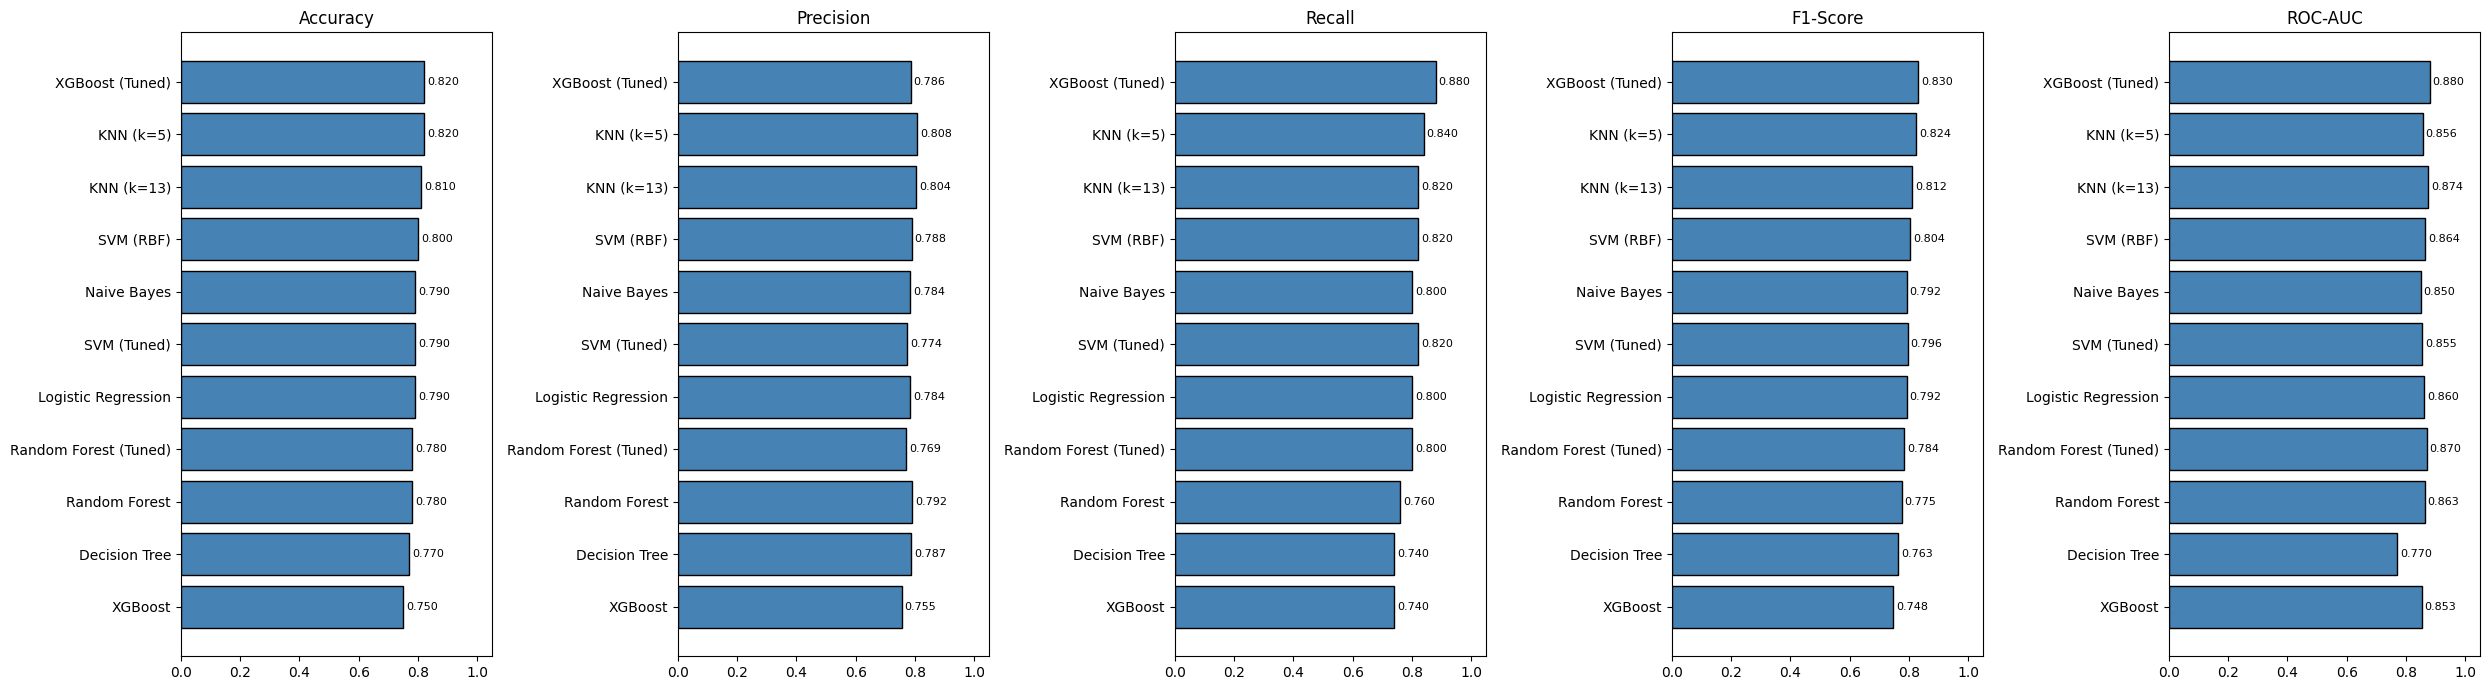

In [38]:
# Bar chart comparison of key metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison_sorted = comparison_df.sort_values(by='Accuracy', ascending=True)

fig, axes = plt.subplots(1, len(metrics), figsize=(25, 7))

for i, metric in enumerate(metrics):
    axes[i].barh(comparison_sorted['Model'], comparison_sorted[metric], color='steelblue', edgecolor='black')
    axes[i].set_title(metric)
    axes[i].set_xlim(0, 1.05)
    for j, v in enumerate(comparison_sorted[metric].values):
        axes[i].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


### 10.3 ROC Curves - Tuned Models


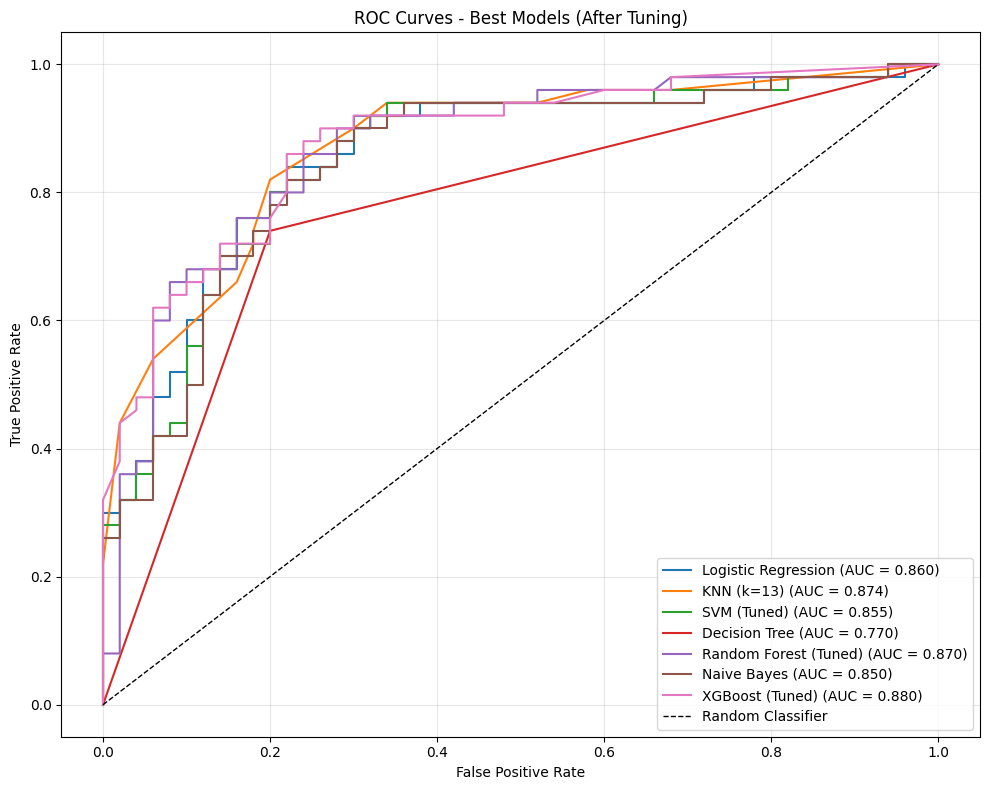

In [39]:
# ROC curves for tuned models only
tuned_results = [lr_results, knn_tuned_results, svm_tuned_results, dt_results,
                 rf_tuned_results, nb_results, xgb_tuned_results]

plt.figure(figsize=(10, 8))
for result in tuned_results:
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    auc_val = result['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{result['Model']} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Best Models (After Tuning)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 10.4 Feature Importance (Random Forest)


Feature Importance (Random Forest - Tuned):
        Feature  Importance
EstimatedSalary    0.560096
            Age    0.430715
         Gender    0.009189


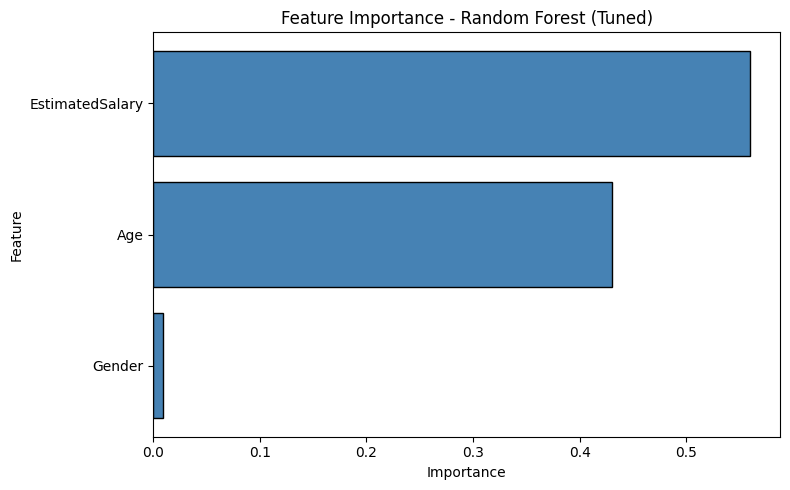

In [40]:
# Feature importance from the best Random Forest model
feature_names = X.columns
importances = rf_grid.best_estimator_.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (Random Forest - Tuned):")
print(feat_imp_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest (Tuned)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---
## 11. Best Model - Detailed Analysis


In [41]:
# Identify the best model by accuracy
best_result = comparison_df.iloc[0]
print(f"Best performing model: {best_result['Model']}")
print(f"Accuracy: {best_result['Accuracy']}")
print(f"Precision: {best_result['Precision']}")
print(f"Recall: {best_result['Recall']}")
print(f"F1-Score: {best_result['F1-Score']}")
print(f"ROC-AUC: {best_result['ROC-AUC']}")


Best performing model: KNN (k=5)
Accuracy: 0.82
Precision: 0.8077
Recall: 0.84
F1-Score: 0.8235
ROC-AUC: 0.8562


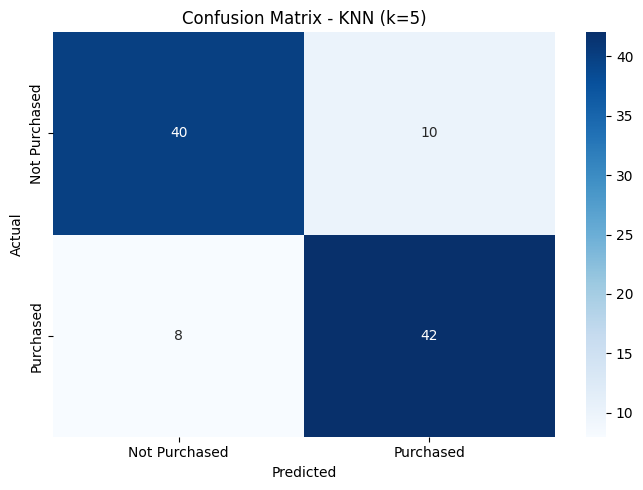

True Negatives: 40
False Positives: 10
False Negatives: 8
True Positives: 42


In [42]:
# Confusion matrix of the best model
best_model_results = None
for r in all_final_results:
    if r['Model'] == best_result['Model']:
        best_model_results = r
        break

cm = confusion_matrix(y_test, best_model_results['y_pred'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.title(f"Confusion Matrix - {best_result['Model']}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")


---
## 12. Conclusion

This notebook presented a complete classification pipeline for predicting purchase behavior from social network advertisement data.

Summary of the work performed:

1. The dataset contained 400 records with 5 columns. After dropping the non-predictive User ID column and encoding Gender, three features (Gender, Age, EstimatedSalary) were used for modeling.

2. Exploratory Data Analysis revealed that both Age and EstimatedSalary are meaningful predictors. Older users with higher salaries showed a stronger tendency to purchase the advertised product.

3. The data was split into 75% training and 25% test sets, with StandardScaler applied to normalize features.

4. Seven classification models were trained and evaluated: Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Naive Bayes, and XGBoost.

5. Hyperparameter tuning via GridSearchCV was performed on KNN, SVM, Random Forest, and XGBoost to optimize their performance.

6. All models were compared on Accuracy, Precision, Recall, F1-Score, and ROC-AUC. The results demonstrate that ensemble methods and kernel-based methods tend to perform well on this dataset due to the non-linear decision boundary between purchasers and non-purchasers.

7. The analysis provides actionable insight: advertising campaigns should prioritize targeting users in higher age and salary brackets to maximize conversion rates.
